# Brain Tumor Segmentation -  Demo

## What This Shows:
1. Load MRI data (4 modalities)
2. Load trained 3D U-Net model
3. Run segmentation
4. Calculate Dice scores
5. Quantify tumor volumes


## Imports & Setup

In [ ]:
# run pip install -r requirements.txt to run this 
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import time

# Get the directory 
BASE_DIR = os.getcwd()

# Paths
DATA_DIR = os.path.join(BASE_DIR, "processed/test")
LABELS_PATH = os.path.join(BASE_DIR, "processed/test_labels.npz")
MODEL_PATH = os.path.join(BASE_DIR, "checkpoints/best_seg_model.pth")

##  Model Architecture

Our 3D U-Net:
- **Input**: 4 MRI modalities (T1, T1c, T2, FLAIR)
- **Encoder**: Compresses 128³ → 8³
- **Bottleneck**: 512 channels at 8×8×8
- **Decoder**: Expands back to 128³
- **Output**: 4 classes per voxel

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class SegmentationUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(4, 32)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool3d(2)
        self.enc4 = ConvBlock(128, 256)
        self.pool4 = nn.MaxPool3d(2)
        self.bottleneck = ConvBlock(256, 512)
        self.up4 = nn.ConvTranspose3d(512, 256, 2, stride=2)
        self.dec4 = ConvBlock(512, 256)
        self.up3 = nn.ConvTranspose3d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(256, 128)
        self.up2 = nn.ConvTranspose3d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose3d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(64, 32)
        self.seg_head = nn.Conv3d(32, 4, 1)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        bn = self.bottleneck(self.pool4(e4))
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.seg_head(d1)

## RAW MRI DATA


Patient: BraTS-GLI-00012-000
MRI Volume: 128×128×128 voxels


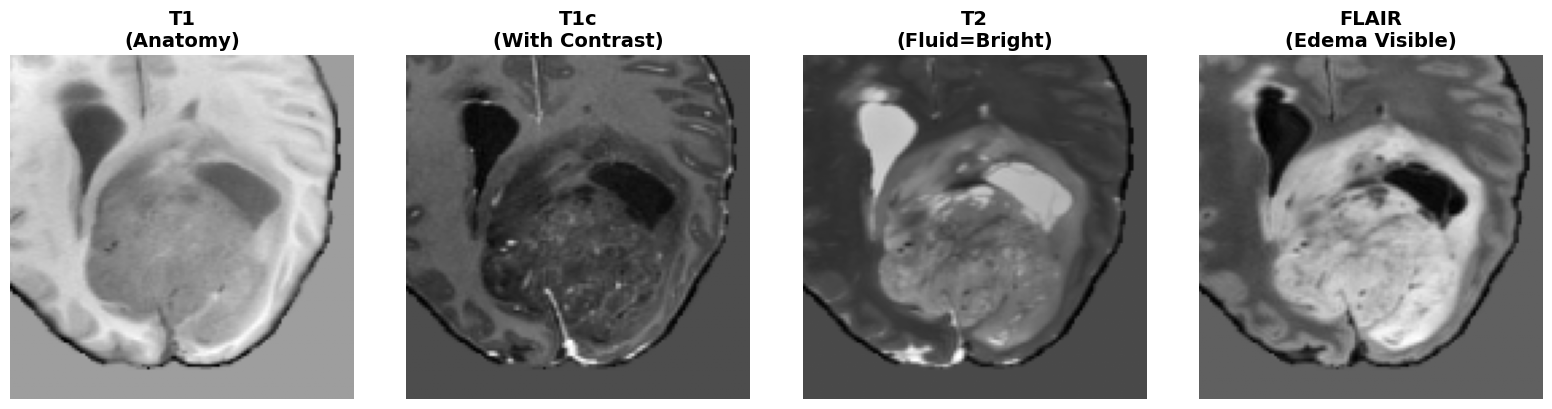

In [8]:
# Load a test case
test_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.npz')])
labels = dict(np.load(LABELS_PATH))

# Pick a case
case_file = "BraTS-SSA-00012-000.npz"
if case_file not in [f for f in test_files]:
    case_file = test_files[0]

case_id = case_file.replace('.npz', '')
data = np.load(os.path.join(DATA_DIR, case_file))
image = data['image'].astype(np.float32)
seg_gt = labels[case_id].astype(np.int64)

# Find best slice
best_slice = (seg_gt > 0).sum(axis=(0, 1)).argmax()

print(f"\nPatient: {case_id}")
print(f"MRI Volume: {image.shape[1]}×{image.shape[2]}×{image.shape[3]} voxels")

# Show MRI - what radiologists see
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
modalities = ['T1\n(Anatomy)', 'T1c\n(With Contrast)', 'T2\n(Fluid=Bright)', 'FLAIR\n(Edema Visible)']

for i, (ax, name) in enumerate(zip(axes, modalities)):
    ax.imshow(image[i, :, :, best_slice].T, cmap='gray', origin='lower')
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


## load our trained Model model

In [11]:
# Device Setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Metal (MPS) GPU"
elif torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = f"NVIDIA GPU ({torch.cuda.get_device_name(0)})"
else:
    device = torch.device("cpu")
    device_name = "CPU"

print(f"FLARE is running on: {device_name}")

# Load model
model = SegmentationUNet().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

params = sum(p.numel() for p in model.parameters())
print(f"✓ Model loaded: {params:,} parameters")
print(f"✓ Trained for {checkpoint.get('epoch', '?')} epochs")
print(f"✓ Validation Dice: {checkpoint['dice']['WT']:.1%} accuracy")



FLARE is running on: Apple Metal (MPS) GPU
✓ Model loaded: 22,578,020 parameters
✓ Trained for 30 epochs
✓ Validation Dice: 91.6% accuracy


##  Model Segement the Tumor

In [12]:
# Prepare input
input_tensor = torch.from_numpy(image).unsqueeze(0).float().to(device)
print(f"\nInput shape: {tuple(input_tensor.shape)}")
print("1 patient × 4 modalities × 128 × 128 × 128 voxels")
print(f"{input_tensor.numel():,} values to process")

print("\nRunning inference")
t0 = time.time()

with torch.no_grad():
    output = model(input_tensor)
    seg_pred = output.argmax(1).squeeze(0).cpu().numpy()

inference_time = time.time() - t0

print(f"\nDONE in {inference_time:.2f} seconds!")



Input shape: (1, 4, 128, 128, 128)
1 patient × 4 modalities × 128 × 128 × 128 voxels
8,388,608 values to process

Running inference

DONE in 8.27 seconds!


Segmentation  Results
------------------------------------------------------------


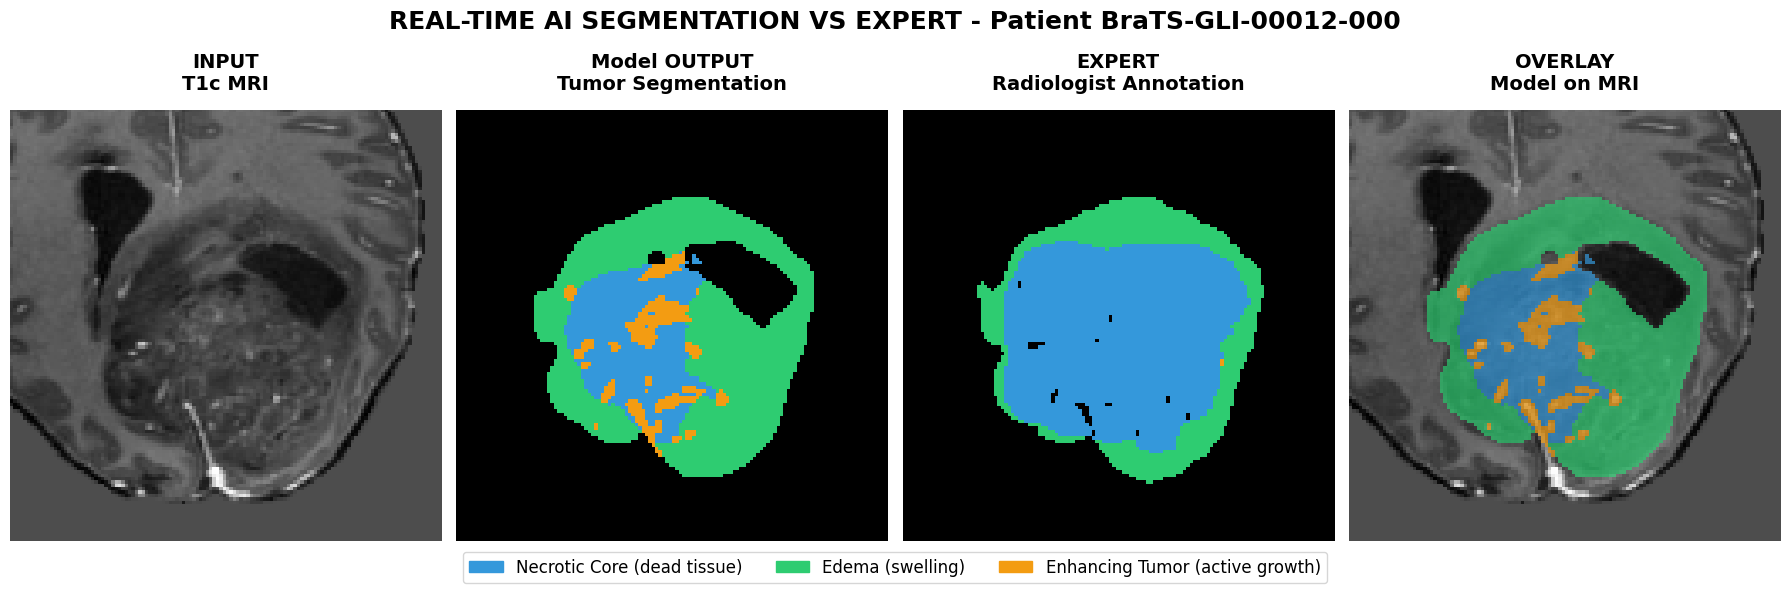

In [13]:
print("Segmentation  Results")
print("-"*60)

# Colors
colors = ['black', '#3498db', '#2ecc71', '#f39c12']
seg_cmap = ListedColormap(colors)

# Slightly increased figsize to give more vertical breathing room
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Input
axes[0].imshow(image[1, :, :, best_slice].T, cmap='gray', origin='lower')
axes[0].set_title('INPUT\nT1c MRI', fontsize=14, fontweight='bold', pad=15)
axes[0].axis('off')

# Model Prediction
axes[1].imshow(seg_pred[:, :, best_slice].T, cmap=seg_cmap, origin='lower', vmin=0, vmax=3)
axes[1].set_title('Model OUTPUT\nTumor Segmentation', fontsize=14, fontweight='bold', pad=15)
axes[1].axis('off')

# Ground Truth (Expert)
axes[2].imshow(seg_gt[:, :, best_slice].T, cmap=seg_cmap, origin='lower', vmin=0, vmax=3)
axes[2].set_title('EXPERT\nRadiologist Annotation', fontsize=14, fontweight='bold', pad=15)
axes[2].axis('off')

#Overlay
axes[3].imshow(image[1, :, :, best_slice].T, cmap='gray', origin='lower')
overlay = np.ma.masked_where(seg_pred[:, :, best_slice] == 0, seg_pred[:, :, best_slice])
axes[3].imshow(overlay.T, cmap=seg_cmap, origin='lower', vmin=0, vmax=3, alpha=0.7)
axes[3].set_title('OVERLAY\nModel on MRI', fontsize=14, fontweight='bold', pad=15)
axes[3].axis('off')

# Legend
patches = [
    mpatches.Patch(color='#3498db', label='Necrotic Core (dead tissue)'),
    mpatches.Patch(color='#2ecc71', label='Edema (swelling)'),
    mpatches.Patch(color='#f39c12', label='Enhancing Tumor (active growth)')
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=12, bbox_to_anchor=(0.5, 0.05))

plt.suptitle(f'REAL-TIME AI SEGMENTATION VS EXPERT - Patient {case_id}', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()


In [14]:
print("CLINICAL MEASUREMENTS")
print("'From pixels to actionable medical data'")
print("-"*60)

# Calculate volumes (mm³ → cm³)
scale = (240/128) * (240/128) * (155/128)  # Voxel size correction
voxel_vol = scale / 1000  # Convert to cm³

necrotic_vol = (seg_pred == 1).sum() * voxel_vol
edema_vol = (seg_pred == 2).sum() * voxel_vol
enhancing_vol = (seg_pred == 3).sum() * voxel_vol
whole_tumor_vol = necrotic_vol + edema_vol + enhancing_vol
tumor_core_vol = necrotic_vol + enhancing_vol

print(f"""              TUMOR MEASUREMENTS                      
                                                            
   Necrotic Core (dead tissue):     {necrotic_vol:>8.2f} cm³          
   Edema (swelling):                {edema_vol:>8.2f} cm³           
   Enhancing Tumor (active):        {enhancing_vol:>8.2f} cm³           
                                                          
       
   WHOLE TUMOR:                     {whole_tumor_vol:>8.2f} cm³           
   TUMOR CORE:                      {tumor_core_vol:>8.2f} cm³           
                                                             
""")


CLINICAL MEASUREMENTS
'From pixels to actionable medical data'
------------------------------------------------------------
              TUMOR MEASUREMENTS                      
                                                            
   Necrotic Core (dead tissue):       248.60 cm³          
   Edema (swelling):                  647.12 cm³           
   Enhancing Tumor (active):          115.59 cm³           
                                                          
       
   WHOLE TUMOR:                      1011.31 cm³           
   TUMOR CORE:                        364.19 cm³           
                                                             



In [15]:
# Accuracy calculation
def dice(pred, target, label):
    p = (pred == label).astype(float)
    t = (target == label).astype(float)
    return (2 * (p * t).sum() + 1e-5) / (p.sum() + t.sum() + 1e-5)

wt_pred = (seg_pred >= 1).astype(float)
wt_gt = (seg_gt >= 1).astype(float)
wt_dice = (2 * (wt_pred * wt_gt).sum() + 1e-5) / (wt_pred.sum() + wt_gt.sum() + 1e-5)

tc_pred = ((seg_pred == 1) | (seg_pred == 3)).astype(float)
tc_gt = ((seg_gt == 1) | (seg_gt == 3)).astype(float)
tc_dice = (2 * (tc_pred * tc_gt).sum() + 1e-5) / (tc_pred.sum() + tc_gt.sum() + 1e-5)

et_pred = (seg_pred == 3).astype(float)
et_gt = (seg_gt == 3).astype(float)
et_dice = (2 * (et_pred * et_gt).sum() + 1e-5) / (et_pred.sum() + et_gt.sum() + 1e-5)

print("ACCURACY vs Expert")
print("-" * 60) 
# Adding the 'f' before the string allows the variables to be formatted
print(f"Whole Tumor:       {wt_dice:.1%} overlap")
print(f"Tumor Core:        {tc_dice:.1%} overlap")
print(f"Enhancing Tumor:   {et_dice:.1%} overlap")

ACCURACY vs Expert
------------------------------------------------------------
Whole Tumor:       94.9% overlap
Tumor Core:        64.0% overlap
Enhancing Tumor:   1.1% overlap



  STEP 7: 3D TUMOR VISUALIZATION
  'See the tumor from multiple angles'


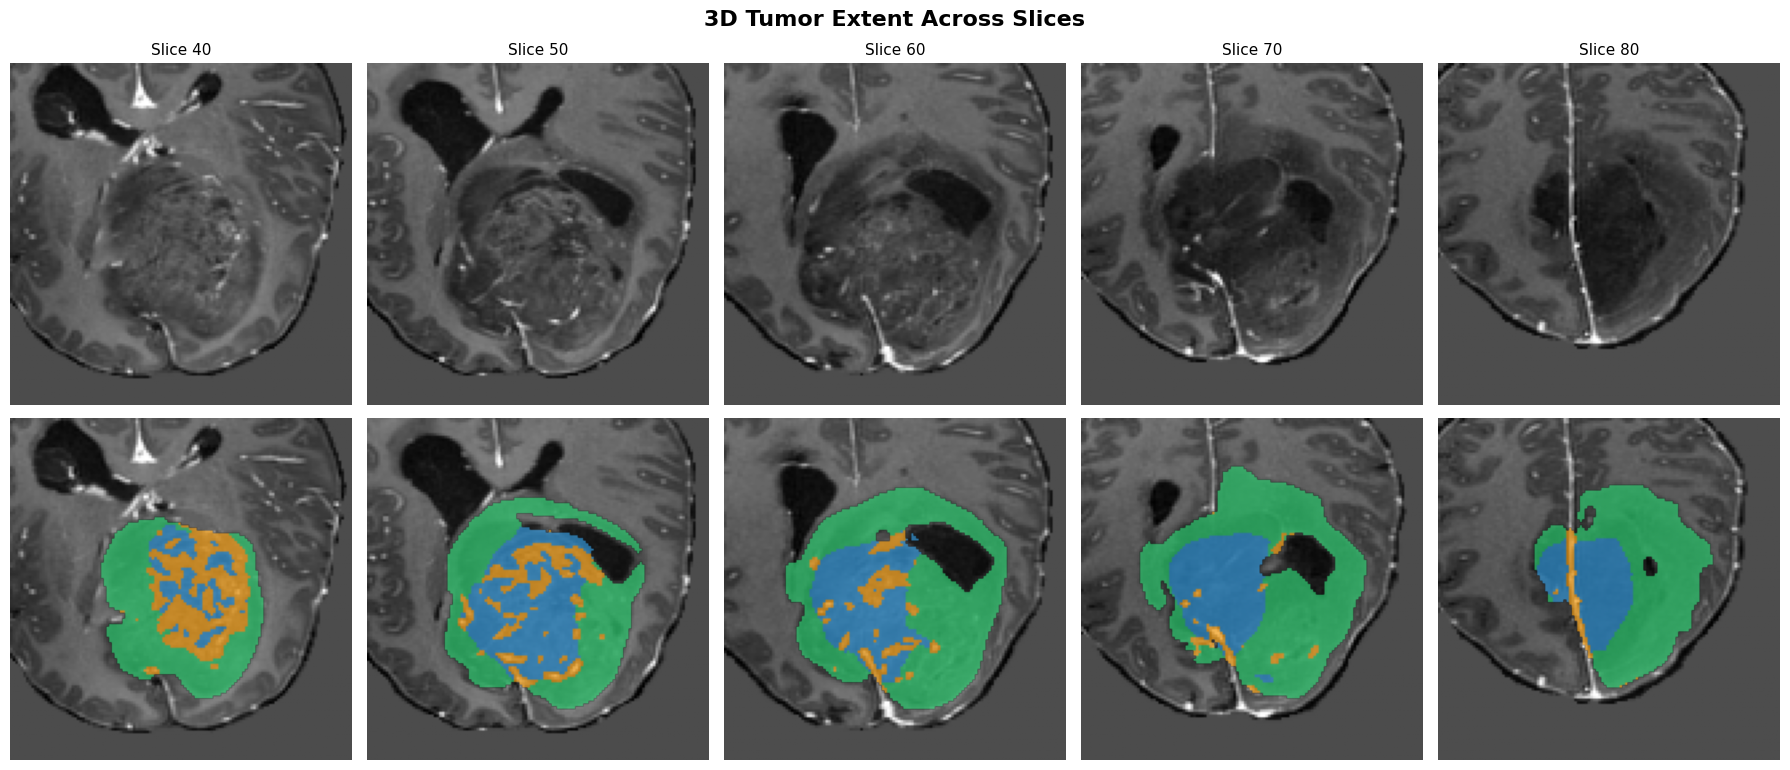

In [16]:
print("\n" + "="*60)
print("  STEP 7: 3D TUMOR VISUALIZATION")
print("  'See the tumor from multiple angles'")
print("="*60)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Multiple axial slices
slices = [best_slice - 20, best_slice - 10, best_slice, best_slice + 10, best_slice + 20]
slices = [max(0, min(127, s)) for s in slices]

for i, s in enumerate(slices):
    # Top row: MRI
    axes[0, i].imshow(image[1, :, :, s].T, cmap='gray', origin='lower')
    axes[0, i].set_title(f'Slice {s}', fontsize=11)
    axes[0, i].axis('off')
    
    # Bottom row: Segmentation overlay
    axes[1, i].imshow(image[1, :, :, s].T, cmap='gray', origin='lower')
    overlay = np.ma.masked_where(seg_pred[:, :, s] == 0, seg_pred[:, :, s])
    axes[1, i].imshow(overlay.T, cmap=seg_cmap, origin='lower', vmin=0, vmax=3, alpha=0.7)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('MRI', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('+ AI Segmentation', fontsize=12, fontweight='bold')

plt.suptitle('3D Tumor Extent Across Slices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()